# Standardized Plays and Team-Week Opportunity

## tl;dr

This notebook converts all 147,928 Bronze play-by-play rows from 2023–2025 into a compact, auditable Silver play table. Source flags remain visible beside canonical classifications for pass attempts, dropbacks, targets, rush attempts, kneels, scrambles, and high-value field-position opportunities.

The classifications produce 1,710 team-week opportunity rows at `team + season + week`. PBP targets and target air yards reconcile exactly to Bronze weekly statistics in every season. PBP passing attempts are one lower in 2025, and PBP rushing attempts are one lower in 2024; both differences trace to single team-games and remain documented source exceptions rather than being repaired manually.

Six season-partitioned Silver Parquet files are written and reloaded successfully: three standardized-play files and three team-week opportunity files.

## Context & Methods

### Scope

- Seasons: 2023–2025
- Notebook mode: data-quality validation and shared Silver construction
- Primary validation lens: opportunity denominators needed for WR features
- Input format: persisted Bronze and Silver Parquet
- Output format: season-partitioned Silver Parquet
- Environment: `sports_dev_env` with pandas

This notebook turns source PBP flags into documented NFL Dream Lab classifications before aggregating team opportunity. The standardized play table retains one row for every Bronze play, including administrative and special-teams rows, so excluded plays remain inspectable. Only eligible statistical plays contribute to the team-week metrics.

### Key assumptions

- The Bronze PBP grain is `game_id + play_id`.
- Schedule data provides canonical season, week, game type, team, and opponent context.
- A standard statistical opportunity must have a team and must not be a `no_play` or two-point attempt.
- Source `pass_attempt` includes sacks, so canonical pass attempts exclude source sacks while dropbacks retain them.
- Spikes remain official pass attempts; kneels remain official rush attempts but are also available through non-kneel totals.
- Scrambles remain rush attempts and are also retained as dropback evidence.
- A target requires a populated `receiver_player_id` on an eligible play.
- Red-zone opportunities begin at the opponent's 20-yard line; goal-line opportunities begin at the 5-yard line.
- An end-zone target has target depth greater than or equal to the yards from scrimmage to the goal line.
- PBP remains authoritative for play-derived team opportunity. Differences from weekly statistics are recorded rather than repaired by description or player name.

## Data

### 1. Set up paths, grains, and source fields

Keep the scope and proposed contracts visible. The two output directories are created only for the datasets built by this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


SEASONS = [2023, 2024, 2025]
PLAY_GRAIN = ["game_id", "play_id"]
TEAM_WEEK_GRAIN = ["team", "season", "week"]

RED_ZONE_MAX_YARDS = 20
GOAL_LINE_MAX_YARDS = 5
POSTSEASON_GAME_TYPES = {"WC", "DIV", "CON", "SB"}

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

BRONZE_DIR = PROJECT_ROOT / "data/bronze"
SILVER_DIR = PROJECT_ROOT / "data/silver"
STANDARDIZED_PLAYS_DIR = SILVER_DIR / "standardized_plays"
TEAM_WEEK_OPPORTUNITY_DIR = SILVER_DIR / "team_week_opportunity"

STANDARDIZED_PLAYS_DIR.mkdir(parents=True, exist_ok=True)
TEAM_WEEK_OPPORTUNITY_DIR.mkdir(parents=True, exist_ok=True)

PBP_COLUMNS = [
    "season",
    "week",
    "season_type",
    "game_id",
    "play_id",
    "posteam",
    "defteam",
    "play_type",
    "desc",
    "yardline_100",
    "goal_to_go",
    "yards_gained",
    "qb_dropback",
    "qb_kneel",
    "qb_spike",
    "qb_scramble",
    "air_yards",
    "penalty",
    "rush_attempt",
    "pass_attempt",
    "sack",
    "touchdown",
    "pass_touchdown",
    "rush_touchdown",
    "two_point_attempt",
    "complete_pass",
    "passer_player_id",
    "receiver_player_id",
    "receiver_player_name",
    "receiving_yards",
    "rusher_player_id",
    "rushing_yards",
    "special_teams_play",
]

SOURCE_FLAG_COLUMNS = [
    "goal_to_go",
    "qb_dropback",
    "qb_kneel",
    "qb_spike",
    "qb_scramble",
    "penalty",
    "rush_attempt",
    "pass_attempt",
    "sack",
    "touchdown",
    "pass_touchdown",
    "rush_touchdown",
    "two_point_attempt",
    "complete_pass",
    "special_teams_play",
]

### 2. Define the classification contract

The source already provides most of the evidence. These canonical fields state how NFL Dream Lab combines that evidence and which denominator each concept supports.

In [2]:
classification_contract = pd.DataFrame(
    [
        [
            "is_standard_stat_eligible",
            "team is present; play_type is not no_play; not a two-point attempt",
            "Common gate for normal opportunity totals",
        ],
        [
            "is_pass_attempt",
            "eligible source pass_attempt and not a source sack",
            "Official team pass-attempt denominator",
        ],
        [
            "is_dropback",
            "eligible source qb_dropback, spike, or canonical pass attempt",
            "Passing-play context including sacks and scrambles",
        ],
        [
            "is_target",
            "eligible play with receiver_player_id",
            "Target and air-yard denominators",
        ],
        [
            "is_rush_attempt",
            "eligible source rush_attempt",
            "Official team rushing attempts, including kneels",
        ],
        [
            "is_non_kneel_rush_attempt",
            "canonical rush attempt excluding qb_kneel",
            "Rushing opportunity without clock-management kneels",
        ],
        [
            "is_designed_rush_attempt",
            "non-kneel rush attempt excluding qb_scramble",
            "Designed rushing opportunity",
        ],
        [
            "is_red_zone_*",
            "canonical opportunity at yardline_100 <= 20",
            "Red-zone opportunity",
        ],
        [
            "is_goal_line_*",
            "canonical opportunity at yardline_100 <= 5",
            "Goal-line opportunity",
        ],
        [
            "is_end_zone_target",
            "target with air_yards >= yardline_100",
            "Target reaching the goal line or end zone",
        ],
    ],
    columns=["canonical_field", "definition", "downstream_use"],
)

classification_contract

,canonical_field,definition,downstream_use
0,is_standard_stat_eligible,team is present; play_type is not no_play; not...,Common gate for normal opportunity totals
1,is_pass_attempt,eligible source pass_attempt and not a source ...,Official team pass-attempt denominator
2,is_dropback,"eligible source qb_dropback, spike, or canonic...",Passing-play context including sacks and scram...
3,is_target,eligible play with receiver_player_id,Target and air-yard denominators
4,is_rush_attempt,eligible source rush_attempt,"Official team rushing attempts, including kneels"
5,is_non_kneel_rush_attempt,canonical rush attempt excluding qb_kneel,Rushing opportunity without clock-management k...
6,is_designed_rush_attempt,non-kneel rush attempt excluding qb_scramble,Designed rushing opportunity
7,is_red_zone_*,canonical opportunity at yardline_100 <= 20,Red-zone opportunity
8,is_goal_line_*,canonical opportunity at yardline_100 <= 5,Goal-line opportunity
9,is_end_zone_target,target with air_yards >= yardline_100,Target reaching the goal line or end zone


### 3. Load the persisted inputs

Play-by-play and schedules build the datasets. Player metadata checks actor identity, while Bronze weekly stats and the existing Silver player-week facts provide reconciliation baselines.

In [3]:
players_path = BRONZE_DIR / "players/players.parquet"
schedule_paths = sorted((BRONZE_DIR / "schedules").glob("*.parquet"))
player_stats_paths = sorted((BRONZE_DIR / "player_stats_weekly").glob("*.parquet"))
pbp_paths = sorted((BRONZE_DIR / "pbp").glob("*.parquet"))
player_week_paths = sorted((SILVER_DIR / "player_week").glob("*.parquet"))

assert players_path.exists()
assert len(schedule_paths) == len(SEASONS)
assert len(player_stats_paths) == len(SEASONS)
assert len(pbp_paths) == len(SEASONS)
assert len(player_week_paths) == len(SEASONS)

players = pd.read_parquet(players_path, columns=["gsis_id"])
schedules = pd.concat(
    [pd.read_parquet(path) for path in schedule_paths],
    ignore_index=True,
)
player_stats = pd.concat(
    [
        pd.read_parquet(
            path,
            columns=[
                "season",
                "week",
                "season_type",
                "game_id",
                "team",
                "attempts",
                "targets",
                "carries",
                "receiving_air_yards",
            ],
        )
        for path in player_stats_paths
    ],
    ignore_index=True,
)
pbp = pd.concat(
    [pd.read_parquet(path, columns=PBP_COLUMNS) for path in pbp_paths],
    ignore_index=True,
)
silver_player_week = pd.concat(
    [
        pd.read_parquet(
            path,
            columns=[
                "season",
                "passing_attempts",
                "receiving_targets",
                "rushing_attempts",
                "receiving_air_yards",
            ],
        )
        for path in player_week_paths
    ],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        ["players identity", len(players), len(players.columns), 1],
        ["schedules", len(schedules), len(schedules.columns), len(schedule_paths)],
        ["weekly player stats", len(player_stats), len(player_stats.columns), len(player_stats_paths)],
        ["play-by-play selected columns", len(pbp), len(pbp.columns), len(pbp_paths)],
        ["Silver player-week reconciliation", len(silver_player_week), len(silver_player_week.columns), len(player_week_paths)],
    ],
    columns=["input", "rows", "columns_loaded", "files"],
)

assert set(pbp["season"].dropna().unique()) == set(SEASONS)
assert set(schedules["season"].dropna().unique()) == set(SEASONS)
assert set(player_stats["season"].dropna().unique()) == set(SEASONS)
assert set(silver_player_week["season"].dropna().unique()) == set(SEASONS)

input_summary

,input,rows,columns_loaded,files
0,players identity,24828,1,1
1,schedules,855,46,3
2,weekly player stats,57048,9,3
3,play-by-play selected columns,147928,33,3
4,Silver player-week reconciliation,79708,5,3


## Results

### 4. Validate PBP grain and schedule context

Every PBP row must match one scheduled game. Plays with an offensive team must identify one of the scheduled teams, and the source defense must agree with the schedule-derived opponent.

In [4]:
assert pbp[PLAY_GRAIN].notna().all().all()
assert not pbp.duplicated(PLAY_GRAIN).any()

schedule_games = schedules[
    ["game_id", "season", "week", "game_type", "home_team", "away_team"]
].copy()
schedule_games["schedule_season_type"] = schedule_games["game_type"].map(
    lambda game_type: "POST" if game_type in POSTSEASON_GAME_TYPES else game_type
)
schedule_games = schedule_games.rename(
    columns={"season": "schedule_season", "week": "schedule_week"}
)

assert not schedule_games.duplicated(["game_id"]).any()

pbp_context = pbp.merge(
    schedule_games,
    on="game_id",
    how="left",
    validate="many_to_one",
    indicator="schedule_join",
)

assert pbp_context["schedule_join"].eq("both").all()
assert pbp_context["season"].eq(pbp_context["schedule_season"]).all()
assert pbp_context["week"].eq(pbp_context["schedule_week"]).all()
assert pbp_context["season_type"].eq(pbp_context["schedule_season_type"]).all()

team_is_home = pbp_context["posteam"].eq(pbp_context["home_team"])
team_is_away = pbp_context["posteam"].eq(pbp_context["away_team"])
assert (pbp_context["posteam"].isna() | team_is_home | team_is_away).all()

canonical_opponent = pd.Series(pd.NA, index=pbp_context.index, dtype="string")
canonical_opponent.loc[team_is_home] = pbp_context.loc[team_is_home, "away_team"]
canonical_opponent.loc[team_is_away] = pbp_context.loc[team_is_away, "home_team"]

assert pbp_context.loc[pbp_context["posteam"].notna(), "defteam"].astype("string").eq(
    canonical_opponent.loc[pbp_context["posteam"].notna()]
).all()

schedule_validation = pd.DataFrame(
    {
        "check": [
            "duplicate game_id + play_id",
            "rows without schedule match",
            "season or week mismatches",
            "offensive teams outside scheduled matchup",
            "source defense disagreements",
        ],
        "exceptions": [0, 0, 0, 0, 0],
    }
)

schedule_validation

,check,exceptions
0,duplicate game_id + play_id,0
1,rows without schedule match,0
2,season or week mismatches,0
3,offensive teams outside scheduled matchup,0
4,source defense disagreements,0


### 5. Normalize the source flags

PBP stores many flags as numeric values with nulls on unrelated play types. Silver converts them to explicit Boolean source evidence while keeping their original meaning visible through the `source_` prefix.

In [5]:
for source_column in SOURCE_FLAG_COLUMNS:
    pbp_context[f"source_{source_column}"] = (
        pbp_context[source_column].fillna(0).eq(1).astype("boolean")
    )

source_flag_summary = pd.DataFrame(
    {
        "source_flag": SOURCE_FLAG_COLUMNS,
        "flagged_rows": [
            int(pbp_context[f"source_{column}"].sum())
            for column in SOURCE_FLAG_COLUMNS
        ],
    }
).sort_values("flagged_rows", ascending=False)

source_flag_summary

,source_flag,flagged_rows
1,qb_dropback,63845
7,pass_attempt,60698
6,rush_attempt,46160
13,complete_pass,36312
14,special_teams_play,19113
5,penalty,10429
0,goal_to_go,7517
9,touchdown,4297
8,sack,4203
4,qb_scramble,3614


### 6. Inspect plays excluded from normal opportunity

`no_play` rows and two-point attempts remain in the standardized play table for auditability, but they do not enter ordinary pass, target, or rush denominators. Penalty flags alone do not exclude a play because declined penalties and plays with an accepted defensive penalty may still produce official statistics.

In [6]:
pbp_context["is_no_play"] = pbp_context["play_type"].eq("no_play").astype("boolean")
pbp_context["is_two_point_attempt"] = pbp_context[
    "source_two_point_attempt"
].astype("boolean")
pbp_context["is_standard_stat_eligible"] = (
    pbp_context["posteam"].notna()
    & ~pbp_context["is_no_play"]
    & ~pbp_context["is_two_point_attempt"]
).astype("boolean")

exclusion_summary = pd.DataFrame(
    [
        ["all Bronze PBP rows", len(pbp_context)],
        ["no_play rows retained but excluded", int(pbp_context["is_no_play"].sum())],
        ["two-point rows retained but excluded", int(pbp_context["is_two_point_attempt"].sum())],
        ["rows without offensive team", int(pbp_context["posteam"].isna().sum())],
        ["rows eligible to contribute standard stats", int(pbp_context["is_standard_stat_eligible"].sum())],
    ],
    columns=["population", "rows"],
)

exclusion_summary

,population,rows
0,all Bronze PBP rows,147928
1,no_play rows retained but excluded,14214
2,two-point rows retained but excluded,410
3,rows without offensive team,8080
4,rows eligible to contribute standard stats,131550


### 7. Create standardized play classifications

Build canonical flags from the normalized source evidence. Pass attempts, sacks, targets, rush attempts, kneels, and scrambles remain separate so later features can select the correct denominator instead of reinterpreting raw PBP independently.

In [7]:
eligible = pbp_context["is_standard_stat_eligible"]

pbp_context["is_sack"] = (eligible & pbp_context["source_sack"]).astype("boolean")
pbp_context["is_pass_attempt"] = (
    eligible
    & pbp_context["source_pass_attempt"]
    & ~pbp_context["source_sack"]
).astype("boolean")
pbp_context["is_qb_spike"] = (
    eligible & pbp_context["source_qb_spike"]
).astype("boolean")
pbp_context["is_qb_kneel"] = (
    eligible & pbp_context["source_qb_kneel"]
).astype("boolean")
pbp_context["is_qb_scramble"] = (
    eligible & pbp_context["source_qb_scramble"]
).astype("boolean")
pbp_context["is_dropback"] = (
    eligible
    & (
        pbp_context["source_qb_dropback"]
        | pbp_context["source_qb_spike"]
        | pbp_context["is_pass_attempt"]
    )
).astype("boolean")
pbp_context["is_target"] = (
    eligible & pbp_context["receiver_player_id"].notna()
).astype("boolean")
pbp_context["is_complete_pass"] = (
    pbp_context["is_target"] & pbp_context["source_complete_pass"]
).astype("boolean")
pbp_context["is_rush_attempt"] = (
    eligible & pbp_context["source_rush_attempt"]
).astype("boolean")
pbp_context["is_non_kneel_rush_attempt"] = (
    pbp_context["is_rush_attempt"] & ~pbp_context["is_qb_kneel"]
).astype("boolean")
pbp_context["is_designed_rush_attempt"] = (
    pbp_context["is_non_kneel_rush_attempt"]
    & ~pbp_context["is_qb_scramble"]
).astype("boolean")

scrimmage_opportunity = pbp_context["is_dropback"] | pbp_context["is_rush_attempt"]
in_red_zone = pbp_context["yardline_100"].between(
    0, RED_ZONE_MAX_YARDS, inclusive="both"
)
at_goal_line = pbp_context["yardline_100"].between(
    0, GOAL_LINE_MAX_YARDS, inclusive="both"
)

pbp_context["is_red_zone_play"] = (
    scrimmage_opportunity & in_red_zone
).astype("boolean")
pbp_context["is_goal_line_play"] = (
    scrimmage_opportunity & at_goal_line
).astype("boolean")
pbp_context["is_red_zone_target"] = (
    pbp_context["is_target"] & in_red_zone
).astype("boolean")
pbp_context["is_goal_line_target"] = (
    pbp_context["is_target"] & at_goal_line
).astype("boolean")
pbp_context["is_end_zone_target"] = (
    pbp_context["is_target"]
    & pbp_context["air_yards"].ge(pbp_context["yardline_100"])
).astype("boolean")
pbp_context["is_red_zone_rush_attempt"] = (
    pbp_context["is_non_kneel_rush_attempt"] & in_red_zone
).astype("boolean")
pbp_context["is_goal_line_rush_attempt"] = (
    pbp_context["is_non_kneel_rush_attempt"] & at_goal_line
).astype("boolean")
pbp_context["target_air_yards"] = pbp_context["air_yards"].where(
    pbp_context["is_target"]
)

### 8. Validate classification relationships and player identities

Check the logical subset relationships before aggregating. Passer, receiver, and rusher identifiers must also match the GSIS player master exactly; names are not used for repair.

In [8]:
assert not (pbp_context["is_pass_attempt"] & pbp_context["is_sack"]).any()
assert not (pbp_context["is_target"] & ~pbp_context["is_pass_attempt"]).any()
assert not (pbp_context["is_complete_pass"] & ~pbp_context["is_target"]).any()
assert not (pbp_context["is_qb_kneel"] & ~pbp_context["is_rush_attempt"]).any()
assert not (pbp_context["is_qb_scramble"] & ~pbp_context["is_rush_attempt"]).any()
assert not (
    pbp_context["is_non_kneel_rush_attempt"] & pbp_context["is_qb_kneel"]
).any()
assert not (
    pbp_context["is_designed_rush_attempt"] & pbp_context["is_qb_scramble"]
).any()
assert not (pbp_context["is_goal_line_target"] & ~pbp_context["is_red_zone_target"]).any()
assert not (
    pbp_context["is_goal_line_rush_attempt"]
    & ~pbp_context["is_red_zone_rush_attempt"]
).any()

derived_flag_columns = [
    "is_pass_attempt",
    "is_dropback",
    "is_sack",
    "is_target",
    "is_complete_pass",
    "is_rush_attempt",
    "is_non_kneel_rush_attempt",
    "is_designed_rush_attempt",
    "is_qb_kneel",
    "is_qb_spike",
    "is_qb_scramble",
    "is_red_zone_play",
    "is_goal_line_play",
    "is_red_zone_target",
    "is_goal_line_target",
    "is_end_zone_target",
    "is_red_zone_rush_attempt",
    "is_goal_line_rush_attempt",
]

assert not pbp_context.loc[
    ~pbp_context["is_standard_stat_eligible"], derived_flag_columns
].any().any()

player_master_ids = set(players["gsis_id"].dropna())
identity_records = []
for player_id_column in [
    "passer_player_id",
    "receiver_player_id",
    "rusher_player_id",
]:
    populated_ids = pbp_context[player_id_column].dropna()
    identity_records.append(
        {
            "source_column": player_id_column,
            "rows_with_id": len(populated_ids),
            "distinct_ids": populated_ids.nunique(),
            "master_match_rate": populated_ids.isin(player_master_ids).mean(),
            "unmatched_ids": len(set(populated_ids) - player_master_ids),
        }
    )

identity_summary = pd.DataFrame(identity_records)
assert identity_summary["master_match_rate"].eq(1.0).all()

classification_summary = pd.DataFrame(
    {
        "classification": derived_flag_columns,
        "rows": [int(pbp_context[column].sum()) for column in derived_flag_columns],
    }
).sort_values("rows", ascending=False)

display(identity_summary)
classification_summary

,source_column,rows_with_id,distinct_ids,master_match_rate,unmatched_ids
0,passer_player_id,60698,193,1.0,0
1,receiver_player_id,53880,759,1.0,0
2,rusher_player_id,46160,564,1.0,0


,classification,rows
1,is_dropback,63783
0,is_pass_attempt,56202
3,is_target,53611
5,is_rush_attempt,46041
6,is_non_kneel_rush_attempt,44698
7,is_designed_rush_attempt,41320
4,is_complete_pass,36312
11,is_red_zone_play,16191
16,is_red_zone_rush_attempt,7935
13,is_red_zone_target,7034


### 9. Create `silver_standardized_plays`

Grain: one row per `game_id + play_id`. The table keeps every Bronze PBP row, normalized schedule context, source evidence, actor identifiers, and the canonical opportunity flags.

In [9]:
pbp_context["opponent_team"] = canonical_opponent

standardized_play_columns = [
    "game_id",
    "play_id",
    "schedule_season",
    "schedule_week",
    "game_type",
    "schedule_season_type",
    "posteam",
    "opponent_team",
    "play_type",
    "desc",
    "yardline_100",
    "source_goal_to_go",
    "yards_gained",
    "air_yards",
    "target_air_yards",
    "receiving_yards",
    "rushing_yards",
    "passer_player_id",
    "receiver_player_id",
    "receiver_player_name",
    "rusher_player_id",
    "source_qb_dropback",
    "source_qb_kneel",
    "source_qb_spike",
    "source_qb_scramble",
    "source_penalty",
    "source_rush_attempt",
    "source_pass_attempt",
    "source_sack",
    "source_touchdown",
    "source_pass_touchdown",
    "source_rush_touchdown",
    "source_two_point_attempt",
    "source_complete_pass",
    "source_special_teams_play",
    "is_no_play",
    "is_two_point_attempt",
    "is_standard_stat_eligible",
] + derived_flag_columns

silver_standardized_plays = pbp_context[standardized_play_columns].rename(
    columns={
        "schedule_season": "season",
        "schedule_week": "week",
        "schedule_season_type": "season_type",
        "posteam": "team",
    }
)

silver_standardized_plays["play_id"] = silver_standardized_plays["play_id"].astype(
    "Int64"
)
for text_column in [
    "game_id",
    "game_type",
    "season_type",
    "team",
    "opponent_team",
    "play_type",
    "desc",
    "passer_player_id",
    "receiver_player_id",
    "receiver_player_name",
    "rusher_player_id",
]:
    silver_standardized_plays[text_column] = silver_standardized_plays[
        text_column
    ].astype("string")

silver_standardized_plays = silver_standardized_plays.sort_values(
    ["season", "game_id", "play_id"]
).reset_index(drop=True)

assert silver_standardized_plays[PLAY_GRAIN].notna().all().all()
assert not silver_standardized_plays.duplicated(PLAY_GRAIN).any()
assert len(silver_standardized_plays) == len(pbp)

pd.DataFrame(
    {
        "dataset": ["silver_standardized_plays"],
        "rows": [len(silver_standardized_plays)],
        "columns": [len(silver_standardized_plays.columns)],
        "grain": [" + ".join(PLAY_GRAIN)],
        "duplicate_grain_rows": [silver_standardized_plays.duplicated(PLAY_GRAIN).sum()],
        "null_grain_rows": [silver_standardized_plays[PLAY_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,silver_standardized_plays,147928,56,game_id + play_id,0,0


### 10. Create `silver_team_week_opportunity`

Aggregate canonical play flags first at player-independent team-game grain, then use the schedule to enforce one row per team and game. The selected seasons contain no multi-game team-weeks, so the final table enforces `team + season + week` while retaining `game_id`.

In [10]:
home_team_games = schedules[
    ["game_id", "season", "week", "game_type", "home_team", "away_team"]
].rename(columns={"home_team": "team", "away_team": "opponent_team"})
away_team_games = schedules[
    ["game_id", "season", "week", "game_type", "away_team", "home_team"]
].rename(columns={"away_team": "team", "home_team": "opponent_team"})

schedule_team_games = pd.concat(
    [home_team_games, away_team_games],
    ignore_index=True,
)
schedule_team_games["season_type"] = schedule_team_games["game_type"].map(
    lambda game_type: "POST" if game_type in POSTSEASON_GAME_TYPES else game_type
)

assert not schedule_team_games.duplicated(["game_id", "team"]).any()
assert not schedule_team_games.duplicated(["season", "week", "team"]).any()

count_metric_columns = [
    "is_dropback",
    "is_pass_attempt",
    "is_sack",
    "is_target",
    "is_complete_pass",
    "is_rush_attempt",
    "is_non_kneel_rush_attempt",
    "is_designed_rush_attempt",
    "is_qb_kneel",
    "is_qb_spike",
    "is_qb_scramble",
    "is_red_zone_target",
    "is_goal_line_target",
    "is_end_zone_target",
    "is_red_zone_rush_attempt",
    "is_goal_line_rush_attempt",
]

team_play_rows = silver_standardized_plays.loc[
    silver_standardized_plays["team"].notna()
].copy()
team_play_rows["target_air_yards_for_sum"] = team_play_rows[
    "target_air_yards"
].fillna(0)

team_game_metrics = (
    team_play_rows.groupby(["game_id", "team"], dropna=False)
    .agg(
        **{
            column.removeprefix("is_"): (column, "sum")
            for column in count_metric_columns
        },
        team_air_yards=("target_air_yards_for_sum", "sum"),
    )
    .reset_index()
)

team_game_metrics = team_game_metrics.rename(
    columns={
        "dropback": "team_dropbacks",
        "pass_attempt": "team_pass_attempts",
        "sack": "team_sacks",
        "target": "team_targets",
        "complete_pass": "team_completions",
        "rush_attempt": "team_rush_attempts",
        "non_kneel_rush_attempt": "team_non_kneel_rush_attempts",
        "designed_rush_attempt": "team_designed_rush_attempts",
        "qb_kneel": "team_qb_kneels",
        "qb_spike": "team_qb_spikes",
        "qb_scramble": "team_qb_scrambles",
        "red_zone_target": "team_red_zone_targets",
        "goal_line_target": "team_goal_line_targets",
        "end_zone_target": "team_end_zone_targets",
        "red_zone_rush_attempt": "team_red_zone_rush_attempts",
        "goal_line_rush_attempt": "team_goal_line_rush_attempts",
    }
)

team_week_opportunity = schedule_team_games.merge(
    team_game_metrics,
    on=["game_id", "team"],
    how="left",
    validate="one_to_one",
    indicator="pbp_join",
)

team_metric_columns = [
    column
    for column in team_game_metrics.columns
    if column not in ["game_id", "team"]
]
count_team_metric_columns = [
    column for column in team_metric_columns if column != "team_air_yards"
]

for metric_column in count_team_metric_columns:
    team_week_opportunity[metric_column] = (
        team_week_opportunity[metric_column].fillna(0).astype("int64")
    )
team_week_opportunity["team_air_yards"] = team_week_opportunity[
    "team_air_yards"
].fillna(0.0)

assert team_week_opportunity["pbp_join"].eq("both").all()
assert team_week_opportunity[TEAM_WEEK_GRAIN].notna().all().all()
assert not team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).any()
assert team_week_opportunity.groupby(TEAM_WEEK_GRAIN)["game_id"].nunique().le(1).all()

silver_team_week_opportunity = (
    team_week_opportunity[
        [
            "team",
            "season",
            "week",
            "game_id",
            "game_type",
            "season_type",
            "opponent_team",
        ]
        + team_metric_columns
    ]
    .sort_values(["season", "week", "team"])
    .reset_index(drop=True)
)

pd.DataFrame(
    {
        "dataset": ["silver_team_week_opportunity"],
        "rows": [len(silver_team_week_opportunity)],
        "columns": [len(silver_team_week_opportunity.columns)],
        "grain": [" + ".join(TEAM_WEEK_GRAIN)],
        "duplicate_grain_rows": [silver_team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).sum()],
        "null_grain_rows": [silver_team_week_opportunity[TEAM_WEEK_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,silver_team_week_opportunity,1710,24,team + season + week,0,0


### 11. Validate team-week metric relationships

The denominators must be nonnegative and preserve their expected subset relationships. Separate official, non-kneel, and designed rushing totals prevent later notebooks from quietly choosing different definitions.

In [11]:
assert silver_team_week_opportunity[count_team_metric_columns].ge(0).all().all()
assert silver_team_week_opportunity["team_pass_attempts"].le(
    silver_team_week_opportunity["team_dropbacks"]
).all()
assert silver_team_week_opportunity["team_targets"].le(
    silver_team_week_opportunity["team_pass_attempts"]
).all()
assert silver_team_week_opportunity["team_completions"].le(
    silver_team_week_opportunity["team_targets"]
).all()
assert silver_team_week_opportunity["team_non_kneel_rush_attempts"].le(
    silver_team_week_opportunity["team_rush_attempts"]
).all()
assert silver_team_week_opportunity["team_designed_rush_attempts"].le(
    silver_team_week_opportunity["team_non_kneel_rush_attempts"]
).all()
assert silver_team_week_opportunity["team_goal_line_targets"].le(
    silver_team_week_opportunity["team_red_zone_targets"]
).all()
assert silver_team_week_opportunity["team_goal_line_rush_attempts"].le(
    silver_team_week_opportunity["team_red_zone_rush_attempts"]
).all()

team_week_season_summary = (
    silver_team_week_opportunity.groupby(["season", "season_type"], dropna=False)
    .agg(
        team_weeks=("game_id", "size"),
        teams=("team", "nunique"),
        games=("game_id", "nunique"),
        pass_attempts=("team_pass_attempts", "sum"),
        targets=("team_targets", "sum"),
        rush_attempts=("team_rush_attempts", "sum"),
        target_air_yards=("team_air_yards", "sum"),
    )
    .reset_index()
)

team_week_season_summary

,season,season_type,team_weeks,teams,games,pass_attempts,targets,rush_attempts,target_air_yards
0,2023,POST,26,14,13,939,890,678,6849.0
1,2023,REG,544,32,272,18315,17483,14606,136213.0
2,2024,POST,26,14,13,769,735,756,6174.0
3,2024,REG,544,32,272,17811,17013,14686,131675.0
4,2025,POST,26,14,13,930,881,714,8266.0
5,2025,REG,544,32,272,17438,16609,14601,130464.0


### 12. Reconcile PBP opportunity with weekly statistics

Targets and target air yards reconcile exactly. One HOU rushing attempt in 2024 Week 15 and one PIT passing attempt in 2025 Week 2 exist in weekly statistics without a corresponding PBP opportunity flag. These are bounded source disagreements, not join or aggregation failures.

In [12]:
bronze_stat_totals = (
    player_stats.groupby("season", dropna=False)
    .agg(
        passing_attempts=("attempts", "sum"),
        receiving_targets=("targets", "sum"),
        rushing_attempts=("carries", "sum"),
        receiving_air_yards=("receiving_air_yards", "sum"),
    )
)

silver_player_week_totals = (
    silver_player_week.groupby("season", dropna=False)
    .agg(
        passing_attempts=("passing_attempts", "sum"),
        receiving_targets=("receiving_targets", "sum"),
        rushing_attempts=("rushing_attempts", "sum"),
        receiving_air_yards=("receiving_air_yards", "sum"),
    )
)

pbp_opportunity_totals = (
    silver_team_week_opportunity.groupby("season", dropna=False)
    .agg(
        passing_attempts=("team_pass_attempts", "sum"),
        receiving_targets=("team_targets", "sum"),
        rushing_attempts=("team_rush_attempts", "sum"),
        receiving_air_yards=("team_air_yards", "sum"),
    )
)

reconciliation_records = []
for season in SEASONS:
    for metric in [
        "passing_attempts",
        "receiving_targets",
        "rushing_attempts",
        "receiving_air_yards",
    ]:
        bronze_total = bronze_stat_totals.loc[season, metric]
        silver_total = silver_player_week_totals.loc[season, metric]
        pbp_total = pbp_opportunity_totals.loc[season, metric]
        reconciliation_records.append(
            {
                "season": season,
                "metric": metric,
                "bronze_weekly_stats": bronze_total,
                "silver_player_week": silver_total,
                "pbp_team_opportunity": pbp_total,
                "silver_minus_bronze": silver_total - bronze_total,
                "pbp_minus_bronze": pbp_total - bronze_total,
            }
        )

opportunity_reconciliation = pd.DataFrame(reconciliation_records)
assert opportunity_reconciliation["silver_minus_bronze"].eq(0).all()

expected_pbp_differences = {
    (2023, "passing_attempts"): 0,
    (2023, "receiving_targets"): 0,
    (2023, "rushing_attempts"): 0,
    (2023, "receiving_air_yards"): 0,
    (2024, "passing_attempts"): 0,
    (2024, "receiving_targets"): 0,
    (2024, "rushing_attempts"): -1,
    (2024, "receiving_air_yards"): 0,
    (2025, "passing_attempts"): -1,
    (2025, "receiving_targets"): 0,
    (2025, "rushing_attempts"): 0,
    (2025, "receiving_air_yards"): 0,
}
observed_pbp_differences = {
    (row.season, row.metric): row.pbp_minus_bronze
    for row in opportunity_reconciliation.itertuples(index=False)
}
assert observed_pbp_differences == expected_pbp_differences

opportunity_reconciliation

,season,metric,bronze_weekly_stats,silver_player_week,pbp_team_opportunity,silver_minus_bronze,pbp_minus_bronze
0,2023,passing_attempts,19254,19254,19254.0,0,0.0
1,2023,receiving_targets,18373,18373,18373.0,0,0.0
2,2023,rushing_attempts,15284,15284,15284.0,0,0.0
3,2023,receiving_air_yards,143062,143062,143062.0,0,0.0
4,2024,passing_attempts,18580,18580,18580.0,0,0.0
5,2024,receiving_targets,17748,17748,17748.0,0,0.0
6,2024,rushing_attempts,15443,15443,15442.0,0,-1.0
7,2024,receiving_air_yards,137849,137849,137849.0,0,0.0
8,2025,passing_attempts,18369,18369,18368.0,0,-1.0
9,2025,receiving_targets,17490,17490,17490.0,0,0.0


In [13]:
bronze_team_game_stats = (
    player_stats.groupby(
        ["season", "week", "season_type", "game_id", "team"],
        dropna=False,
    )
    .agg(
        passing_attempts=("attempts", "sum"),
        receiving_targets=("targets", "sum"),
        rushing_attempts=("carries", "sum"),
        receiving_air_yards=("receiving_air_yards", "sum"),
    )
    .reset_index()
)

team_game_reconciliation = silver_team_week_opportunity.merge(
    bronze_team_game_stats,
    on=["season", "week", "season_type", "game_id", "team"],
    how="outer",
    validate="one_to_one",
    suffixes=("_pbp", "_stats"),
    indicator="source_join",
)

metric_pairs = {
    "passing_attempts": ("team_pass_attempts", "passing_attempts"),
    "receiving_targets": ("team_targets", "receiving_targets"),
    "rushing_attempts": ("team_rush_attempts", "rushing_attempts"),
    "receiving_air_yards": ("team_air_yards", "receiving_air_yards"),
}
for metric, (pbp_column, stats_column) in metric_pairs.items():
    team_game_reconciliation[f"{metric}_difference"] = (
        team_game_reconciliation[pbp_column].fillna(0)
        - team_game_reconciliation[stats_column].fillna(0)
    )

difference_columns = [
    f"{metric}_difference" for metric in metric_pairs
]
source_reconciliation_exceptions = team_game_reconciliation.loc[
    team_game_reconciliation[difference_columns].ne(0).any(axis=1),
    [
        "season",
        "week",
        "game_id",
        "team",
        "opponent_team",
        "source_join",
    ]
    + difference_columns,
].copy()

assert set(
    source_reconciliation_exceptions[["game_id", "team"]].itertuples(
        index=False, name=None
    )
) == {
    ("2024_15_MIA_HOU", "HOU"),
    ("2025_02_SEA_PIT", "PIT"),
}

source_reconciliation_exceptions

,season,week,game_id,team,opponent_team,source_join,passing_attempts_difference,receiving_targets_difference,rushing_attempts_difference,receiving_air_yards_difference
1006,2024,15,2024_15_MIA_HOU,HOU,MIA,both,0,0,-1,0.0
1196,2025,2,2025_02_SEA_PIT,PIT,SEA,both,-1,0,0,0.0


### 13. Inspect team-week opportunity distributions

The distributions make implausible or extreme denominators easier to spot than a long table. Exact values remain available in the following team-week sample.

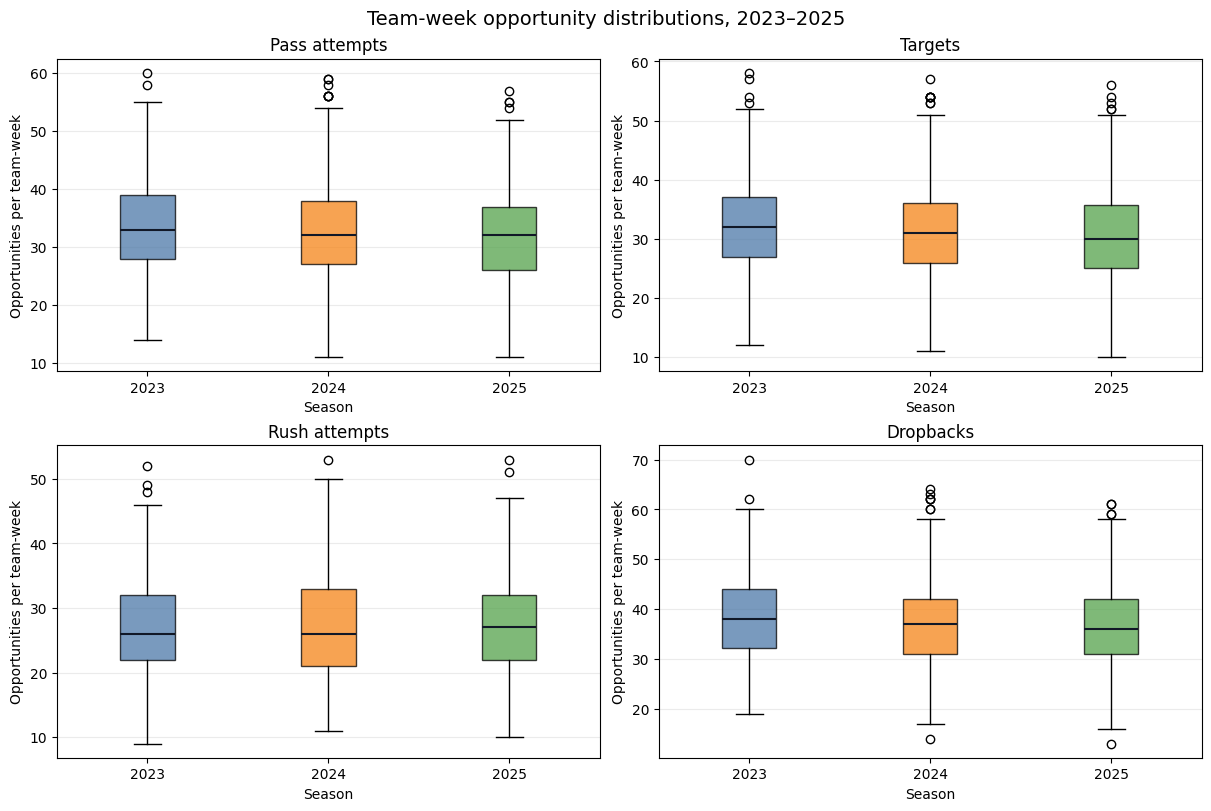

In [14]:
plot_metrics = {
    "team_pass_attempts": "Pass attempts",
    "team_targets": "Targets",
    "team_rush_attempts": "Rush attempts",
    "team_dropbacks": "Dropbacks",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
season_colors = ["#4C78A8", "#F58518", "#54A24B"]

for axis, (metric, title) in zip(axes.flat, plot_metrics.items()):
    season_values = [
        silver_team_week_opportunity.loc[
            silver_team_week_opportunity["season"] == season,
            metric,
        ]
        for season in SEASONS
    ]
    boxplot = axis.boxplot(
        season_values,
        tick_labels=[str(season) for season in SEASONS],
        patch_artist=True,
        medianprops={"color": "#111827", "linewidth": 1.5},
    )
    for patch, color in zip(boxplot["boxes"], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axis.set_title(title)
    axis.set_xlabel("Season")
    axis.set_ylabel("Opportunities per team-week")
    axis.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Team-week opportunity distributions, 2023–2025",
    fontsize=14,
)
plt.show()

The season distributions have similar centers and spreads, with no visible structural break across 2023–2025. The highest-volume weeks appear as bounded outliers rather than a separate population; the next table keeps their exact team, week, and opponent context visible.

In [15]:
recognizable_team_weeks = (
    silver_team_week_opportunity[
        [
            "season",
            "week",
            "season_type",
            "team",
            "opponent_team",
            "team_dropbacks",
            "team_pass_attempts",
            "team_targets",
            "team_rush_attempts",
            "team_red_zone_targets",
            "team_end_zone_targets",
        ]
    ]
    .sort_values(["team_targets", "team_pass_attempts"], ascending=False)
    .head(12)
)

recognizable_team_weeks

,season,week,season_type,team,opponent_team,team_dropbacks,team_pass_attempts,team_targets,team_rush_attempts,team_red_zone_targets,team_end_zone_targets
546,2023,19,POST,DAL,GB,70,60,58,25,11,6
68,2023,3,REG,CAR,SEA,62,58,57,14,1,1
935,2024,13,REG,CLE,DEN,62,58,57,23,7,5
1438,2025,11,REG,ARI,SF,57,57,56,14,10,2
699,2024,5,REG,ATL,TB,63,59,54,18,2,0
996,2024,15,REG,DET,BUF,64,59,54,15,12,3
852,2024,10,REG,CIN,BAL,60,56,54,16,8,5
880,2024,11,REG,DAL,HOU,62,56,54,18,1,2
1341,2025,7,REG,LAC,IND,61,55,54,16,11,7
21,2023,1,REG,NE,PHI,58,54,54,22,7,4


### 14. Save and verify the Silver Parquet files

Write each dataset by season and immediately reload it. Shape, columns, dtypes, season membership, and declared grain must survive the round trip.

In [16]:
output_records = []

for season in SEASONS:
    standardized_plays_path = (
        STANDARDIZED_PLAYS_DIR / f"standardized_plays_{season}.parquet"
    )
    standardized_plays_partition = silver_standardized_plays.loc[
        silver_standardized_plays["season"] == season
    ].copy()
    standardized_plays_partition.to_parquet(standardized_plays_path, index=False)
    standardized_plays_reloaded = pd.read_parquet(standardized_plays_path)

    assert standardized_plays_reloaded.shape == standardized_plays_partition.shape
    assert (
        standardized_plays_reloaded.columns.tolist()
        == standardized_plays_partition.columns.tolist()
    )
    assert (
        standardized_plays_reloaded.dtypes.astype(str).tolist()
        == standardized_plays_partition.dtypes.astype(str).tolist()
    )
    assert set(standardized_plays_reloaded["season"].unique()) == {season}
    assert not standardized_plays_reloaded.duplicated(PLAY_GRAIN).any()

    output_records.append(
        {
            "dataset": "standardized_plays",
            "season": season,
            "rows": len(standardized_plays_reloaded),
            "columns": len(standardized_plays_reloaded.columns),
            "grain": " + ".join(PLAY_GRAIN),
            "duplicate_grain_rows": standardized_plays_reloaded.duplicated(PLAY_GRAIN).sum(),
            "file_mb": round(standardized_plays_path.stat().st_size / 1024**2, 2),
            "round_trip_passed": True,
        }
    )

    team_week_path = (
        TEAM_WEEK_OPPORTUNITY_DIR / f"team_week_opportunity_{season}.parquet"
    )
    team_week_partition = silver_team_week_opportunity.loc[
        silver_team_week_opportunity["season"] == season
    ].copy()
    team_week_partition.to_parquet(team_week_path, index=False)
    team_week_reloaded = pd.read_parquet(team_week_path)

    assert team_week_reloaded.shape == team_week_partition.shape
    assert team_week_reloaded.columns.tolist() == team_week_partition.columns.tolist()
    assert (
        team_week_reloaded.dtypes.astype(str).tolist()
        == team_week_partition.dtypes.astype(str).tolist()
    )
    assert set(team_week_reloaded["season"].unique()) == {season}
    assert not team_week_reloaded.duplicated(TEAM_WEEK_GRAIN).any()

    output_records.append(
        {
            "dataset": "team_week_opportunity",
            "season": season,
            "rows": len(team_week_reloaded),
            "columns": len(team_week_reloaded.columns),
            "grain": " + ".join(TEAM_WEEK_GRAIN),
            "duplicate_grain_rows": team_week_reloaded.duplicated(TEAM_WEEK_GRAIN).sum(),
            "file_mb": round(team_week_path.stat().st_size / 1024**2, 2),
            "round_trip_passed": True,
        }
    )

silver_output_summary = pd.DataFrame(output_records)
assert silver_output_summary["round_trip_passed"].all()
assert silver_output_summary["duplicate_grain_rows"].eq(0).all()

display(silver_output_summary)
print(f"Files written: {len(silver_output_summary)}")
print(f"Total rows written: {silver_output_summary['rows'].sum():,}")
print(f"Total Parquet size: {silver_output_summary['file_mb'].sum():,.2f} MB")

,dataset,season,rows,columns,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,standardized_plays,2023,49665,56,game_id + play_id,0,2.11,True
1,team_week_opportunity,2023,570,24,team + season + week,0,0.03,True
2,standardized_plays,2024,49492,56,game_id + play_id,0,2.14,True
3,team_week_opportunity,2024,570,24,team + season + week,0,0.03,True
4,standardized_plays,2025,48771,56,game_id + play_id,0,2.14,True
5,team_week_opportunity,2025,570,24,team + season + week,0,0.03,True


Files written: 6
Total rows written: 149,638
Total Parquet size: 6.48 MB


## Takeaways

- The complete 147,928-row Bronze PBP population survives at the `game_id + play_id` Silver grain with no missing or duplicate keys.
- Source flags remain visible beside canonical classifications, so downstream denominators are explainable and auditable.
- `no_play` rows and two-point attempts remain available for inspection but do not enter ordinary opportunity totals. Penalty rows are not excluded automatically.
- All populated passer, receiver, and rusher GSIS identifiers match the player master.
- The schedule produces 1,710 unique team-weeks, and every team-week has matching PBP opportunity evidence.
- PBP targets and receiving air yards reconcile exactly to Bronze weekly stats for all three seasons.
- Two bounded source differences remain: HOU has one fewer PBP rush than weekly-stat carries in 2024 Week 15, and PIT has one fewer PBP pass attempt than weekly-stat attempts in 2025 Week 2.
- Official rush attempts, non-kneel rush attempts, and designed rush attempts are stored separately. The later QB notebook can define meaningful QB rushing without rebuilding play classifications.
- `standardized_plays` and `team_week_opportunity` are persisted by season and pass schema, dtype, grain, partition, and round-trip checks.
- The next Silver notebook can build WR weekly facts using shared player-week statistics, participation, PBP classifications, and team-week denominators.